# Recurrent backend example

This notebook walks through an end-to-end workflow with the `recurrent`
backend: compile a cyclic graph, train a small model, and interpret named
nodes.

It assumes you have already read the [Getting started](getting-started.ipynb)
notebook. That tutorial covers package basics, feature alignment, and the
overall `edge2torch` workflow. Here we focus on what changes when the graph
contains cycles and the model is compiled as a recurrent state-update
network.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from graphviz import Digraph
from IPython.display import display
from torch import nn

import edge2torch as e2t

sns.set_theme(style="whitegrid")

## Define a cyclic regulatory graph

The `recurrent` backend allows cycles among internal nodes. In this toy
example, two regulators exchange feedback while one informative input feature
drives the signal branch.

- `gene_signal` feeds `regulator_a`
- `gene_noise` feeds `regulator_b`
- `regulator_a` and `regulator_b` form a feedback loop
- `regulator_a` connects to the output node `phenotype_1`

In [2]:
edgelist = pd.DataFrame(
    {
        "source": [
            "gene_signal",
            "gene_noise",
            "regulator_a",
            "regulator_b",
            "regulator_a",
        ],
        "target": [
            "regulator_a",
            "regulator_b",
            "regulator_b",
            "regulator_a",
            "phenotype_1",
        ],
    }
)

edgelist

,source,target
0,gene_signal,regulator_a
1,gene_noise,regulator_b
2,regulator_a,regulator_b
3,regulator_b,regulator_a
4,regulator_a,phenotype_1


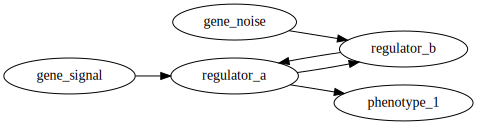

In [3]:
dot = Digraph()
dot.attr(rankdir="LR")

input_nodes = ["gene_signal", "gene_noise"]
state_nodes = ["regulator_a", "regulator_b"]
output_nodes = ["phenotype_1"]

for node_name in input_nodes:
    dot.node(node_name, node_name)

for node_name in state_nodes:
    dot.node(node_name, node_name)

for node_name in output_nodes:
    dot.node(node_name, node_name)

for row in edgelist.itertuples(index=False):
    dot.edge(str(row.source), str(row.target))

dot

## Compile with `backend="recurrent"`

Use the `steps` argument to control how many state-update steps are unrolled
during compilation. Node interpretation sites are exposed as `step_1`,
`step_2`, and so on.

In [4]:
model, artifact = e2t.compile_graph(
    edgelist=edgelist,
    backend="recurrent",
    steps=2,
    quiet=True,
)

artifact.backend, list(artifact.interpretation_sites.keys())

('recurrent', ['step_1', 'step_2'])

## Simulate data, align features, and train

In [5]:
def simulate_binary_data(
    n_per_class,
    feature_names,
    informative_features,
    rng,
):
    n_features = len(feature_names)
    n_samples = 2 * n_per_class

    x = rng.normal(0.0, 1.0, size=(n_samples, n_features))
    y = np.array([0] * n_per_class + [1] * n_per_class)

    informative_idx = [
        feature_names.index(feature_name)
        for feature_name in informative_features
    ]

    for class_value, shift in enumerate([-1.5, 1.5]):
        class_mask = y == class_value
        for feature_idx in informative_idx:
            x[class_mask, feature_idx] += shift

    x_df = pd.DataFrame(x, columns=feature_names)
    y_series = pd.Series(y, name="label")

    return x_df, y_series

In [6]:
rng = np.random.default_rng(0)

x_train_df, y_train = simulate_binary_data(
    n_per_class=80,
    feature_names=artifact.feature_names,
    informative_features=["gene_signal"],
    rng=rng,
)

x_test_df, y_test = simulate_binary_data(
    n_per_class=40,
    feature_names=artifact.feature_names,
    informative_features=["gene_signal"],
    rng=rng,
)

x_train_df.head()

,gene_noise,gene_signal
0,0.125730,-1.632105
1,0.640423,-1.395100
2,-0.535669,-1.138405
3,1.304000,-0.552919
4,-0.703735,-2.765421


Loss before first update: 0.7288
Loss after final update:  0.1909


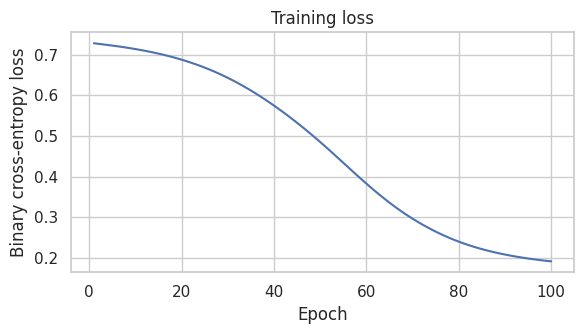

In [7]:
torch.manual_seed(0)

x_train = e2t.align_features_to_input_nodes(
    data=x_train_df,
    artifact=artifact,
)
x_test = e2t.align_features_to_input_nodes(
    data=x_test_df,
    artifact=artifact,
)

customized_model = e2t.customize_model(
    model=model,
    head=nn.Linear(1, 1),
)

y_train_tensor = torch.tensor(
    y_train.values.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(customized_model.parameters(), lr=1e-2)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 100
loss_history = []

customized_model.train()

for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = customized_model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print("Loss before first update:", round(loss_history[0], 4))
print("Loss after final update: ", round(loss_history[-1], 4))

plt.figure(figsize=(6, 3.5))
plt.plot(range(1, n_epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## Interpret nodes

By default, `interpret_model(..., target="nodes")` returns one summary
`pandas.DataFrame` with hidden nodes only.

For recurrent models, repeated node columns across steps are aggregated with
`site_aggregation="max_abs"` by default. Use `level="sites"` to inspect
per-step tables keyed by `step_1`, `step_2`, and so on.

In [8]:
node_importance = e2t.interpret_model(
    model=customized_model,
    artifact=artifact,
    data=x_test_df,
    target="nodes",
    method="LayerConductance",
    quiet=True,
)

node_importance.head()

,regulator_a,regulator_b
0,-4.375947,0.0
1,-2.549415,0.0
2,-3.433526,0.0
3,-3.991350,0.0
4,-3.811052,0.0


In [9]:
node_attr_by_site = e2t.interpret_model(
    model=customized_model,
    artifact=artifact,
    data=x_test_df,
    target="nodes",
    method="LayerConductance",
    level="sites",
    nodes="non_input",
    quiet=True,
)

list(node_attr_by_site.keys())

['step_1', 'step_2']

In [10]:
for site_id, site_df in node_attr_by_site.items():
    print(site_id)
    display(site_df.head())

step_1


,phenotype_1,regulator_a,regulator_b
0,0.0,-4.375947,0.0
1,0.0,-2.549415,0.0
2,0.0,-3.433526,0.0
3,0.0,-3.991350,0.0
4,0.0,-3.811052,0.0


step_2


,phenotype_1,regulator_a,regulator_b
0,-4.375947,0.0,0.0
1,-2.549415,0.0,0.0
2,-3.433526,0.0,0.0
3,-3.991350,0.0,0.0
4,-3.811052,0.0,0.0


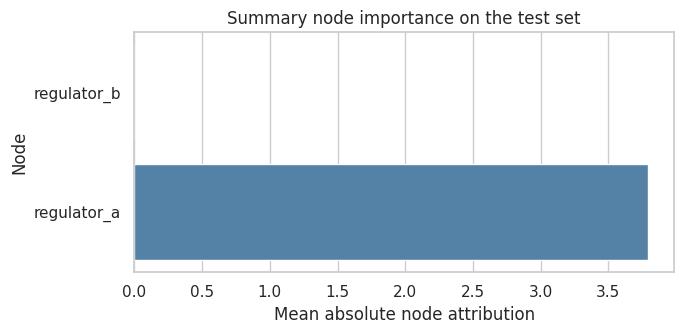

In [11]:
summary_plot = (
    node_importance.abs()
    .mean(axis=0)
    .sort_values(ascending=True)
    .rename("mean_abs_attribution")
    .reset_index()
    .rename(columns={"index": "node"})
)

plt.figure(figsize=(7, 3.5))
sns.barplot(
    data=summary_plot,
    x="mean_abs_attribution",
    y="node",
    color="steelblue",
)
plt.xlabel("Mean absolute node attribution")
plt.ylabel("Node")
plt.title("Summary node importance on the test set")
plt.tight_layout()
plt.show()

## Next steps

- Compare `site_aggregation="mean_abs"` or `"last"` on the same graph
- Read [Backends](backends.md) for recurrent semantics and interpretation
  options
- Return to [Getting started](getting-started.ipynb) for feedforward basics